### Libraries and Imports


In [64]:
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.spatial import KDTree
from scipy.interpolate import RegularGridInterpolator
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3.common.vec_env import SubprocVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback, CheckpointCallback
from sb3_contrib import MaskablePPO
from sb3_contrib.common.wrappers import ActionMasker
from datetime import date
%matplotlib inline
from trajectory_video import make_trajectory_video
from trajectory_video2 import make_trajectory_video1
from training_progress_video import make_training_progress_video
import re
import glob
import matplotlib as mpl
import matplotlib.animation as animation
import imageio_ffmpeg
mpl.rcParams["animation.ffmpeg_path"] = imageio_ffmpeg.get_ffmpeg_exe()

### PDE and FD reference Parameters and RL action space


In [65]:
# PDE 
alpha = 0.05

#   FD reference grid   
nx    = 100
T     = 1
x_fd  = np.linspace(0.0, 1.0, nx)
dx    = x_fd[1] - x_fd[0]

dt_cfl = 0.45 * dx**2 / alpha
nt     = max(int(np.ceil(T / dt_cfl)) + 1, 10)
t_fd   = np.linspace(0.0, T, nt)
dt     = t_fd[1] - t_fd[0]

#  True solution; Analytical diffusion solution

def u_true(x, t):
    return np.sin(np.pi * x) * np.exp(-alpha * np.pi**2 * t)

 

### FD For diffusion

In [66]:
def build_fd_reference():
    u = np.zeros((nx, nt))
    u[:, 0] = u_true(x_fd, 0.0)

    r_diff = alpha * dt / dx**2

    for it in range(nt - 1):
        un = u[:, it]
        u[1:-1, it+1] = (un[1:-1]
                         + r_diff * (un[2:] - 2*un[1:-1] + un[:-2]))
        u[0,   it+1] = 0.0
        u[-1,  it+1] = 0.0

    interp = RegularGridInterpolator(
        (x_fd, t_fd), u, method='linear',
            bounds_error=False, fill_value=None
    )
    return u, interp

### __ init __

In [67]:
class VisitedSet:

    def __init__(self, rebuild_every=200):
        self._pts           = []
        self._norm          = []
        self._tree          = None
        self._dirty         = 0
        self._rebuild_every = rebuild_every
        self._idx_set       = set()               
        self.rejected_history = []  # (x, t) per rejected move
    def add(self, x, t, u):
        self._idx_set.add((round(x / dx), round(t / dt)))  
        self._pts.append((x, t, u))
        self._norm.append((x / dx, t / dt))
        self._dirty += 1
        if self._dirty >= self._rebuild_every:
            self._rebuild()
    def _rebuild(self):
        self._tree  = KDTree(np.array(self._norm))
        self._dirty = 0
    def contains(self, x, t):                    
        return (round(x / dx), round(t / dt)) in self._idx_set
    def find_neighbours(self, x_star, t_star, n):
        if len(self._pts) < n:
            return None
        pts_arr  = np.asarray(self._pts)
        norm_arr = np.asarray(self._norm)

        # causal filter: neighbours at or before the query time
        mask = pts_arr[:, 1] <= t_star

        # a point can never be its own neighbour: exclude the exact query cell
        same_cell = (np.round(pts_arr[:, 0] / dx) == round(x_star / dx)) & \
                    (np.round(pts_arr[:, 1] / dt) == round(t_star / dt))
        mask &= ~same_cell

        if mask.sum() < n:
            return None
        norm_c = norm_arr[mask]
        pts_c  = pts_arr[mask]
        target = np.array([x_star / dx, t_star / dt])
        d2     = np.sum((norm_c - target) ** 2, axis=1)
        idx = np.argpartition(d2, n - 1)[:n]
        idx = idx[np.argsort(d2[idx])]
        return [tuple(row) for row in pts_c[idx]]

    def __len__(self):
            return len(self._pts)

### GFDM Solver


In [68]:
def solve_weights(dx_i, dt_i):
    h = max(np.max(np.abs(dx_i)), 1e-12)

    A = np.array([
        np.ones(len(dx_i)),
        dx_i / h,
        (0.5 * dx_i**2 + alpha * dt_i) / h**2,
    ])
    b = np.array([1.0, 0.0, 0.0])

    #cond = np.linalg.cond(A)
    #if cond > 1e4:
    #    return None, 'cond'

    w = np.linalg.lstsq(A, b, rcond=None)[0]

    #if np.max(np.abs(w)) > 3.0 / len(dx_i):
    #    return None, 'weights'
    #if np.min(w) < -1.0:
    #    return None, 'weights'

    return w, 'ok'

### PDEEnvironment

In [69]:
class PDEEnvironment(gym.Env):
    ACTIONS = {0: (-1, 1),
               1: ( 0, 1),
               2: ( 1, 1)}

    def __init__(self, t_star_schedule=None, t_star_steps=2, N_particles=27,
                 lam=0.001, beta=100.0, K_max=5000, c_shape=0.0,
                 x_star_schedule=None):
        super().__init__()

        self.alpha = alpha
        self.c_shape = c_shape

        # ── Reward-shape constants: fixed, not tuned ──
        self.ERR_CEIL = 2.1    # provable max error: |u_hat| ≤ 1.1 + |u_true| ≤ 1 (documentation)
        self.E_CAP    = 0.05   # errors worse than this are "equally failed"
        self.MARGIN   = 1.0    # fail sits strictly below the worst possible reach

        self.nx = nx; self.nt = nt
        self.x_fd = x_fd; self.t_fd = t_fd
        self.dx = dx; self.dt = dt; self.T = T

        self.t_star_schedule = dict(t_star_schedule) if t_star_schedule else None

        if x_star_schedule is not None:
            self.x_star_choices = np.array(
                [self.x_fd[int(ix)] for ix in x_star_schedule], dtype=float)
        else:
            self.x_star_choices = None

        # ── Target point (z*) ──
        self.x_star = self.x_fd[self.nx // 2]
        self.t_star_steps = t_star_steps
        self.t_star = t_star_steps * dt

        self.K_max = K_max
        self.lam = lam
        self.beta = beta
        self.n_neighbours = 5
        self.eps_x = 0.5 * dx
        self.eps_t = 0.5 * dt

        # ── Walker initial positions: FROZEN to domain center, INDEPENDENT of x* ──
        self.N = N_particles
        mid = self.nx // 2
        margin = 2
        half_n = self.N // 2
        step = (mid - margin) / half_n if half_n > 0 else 0
        offsets = [0]; k = 1
        while len(offsets) < self.N:
            offsets.append(k * step)
            if len(offsets) < self.N:
                offsets.append(-k * step)
            k += 1
        init_idx = np.clip(
            np.round(np.array(offsets[:self.N]) + mid).astype(int),
            margin, self.nx - 1 - margin)
        self.walker_init_x = self.x_fd[init_idx]

        _, self.fd_interp = build_fd_reference()

        self.visited = None
        self.walker_x = None
        self.walker_t = None
        self.walker_u = None
        self.step_count = 0
        self.stencil_log = {}

        # obs: 2N relative coords + t*_norm + x*_norm  → 2N+2
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(2 * self.N + 2,), dtype=np.float32)
        self.action_space = spaces.Discrete(self.N * len(self.ACTIONS))

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        if self.t_star_schedule is not None:
            choices = list(self.t_star_schedule.keys())
            self.t_star_steps = int(self.np_random.choice(choices))
            self.t_star = self.t_star_steps * self.dt
            self.K_max = self.t_star_schedule[self.t_star_steps]

        if self.x_star_choices is not None:
            self.x_star = float(self.np_random.choice(self.x_star_choices))

        self.visited = VisitedSet()
        self.stencil_log = {}

        for ix in range(self.nx):
            x = self.x_fd[ix]
            self.visited.add(x, 0.0, u_true(x, 0.0))
        for it in range(1, self.nt):
            self.visited.add(0.0, self.t_fd[it], 0.0)
            self.visited.add(1.0, self.t_fd[it], 0.0)

        self.walker_x = np.array(self.walker_init_x, dtype=float)
        self.walker_t = np.zeros(self.N)
        self.walker_u = np.array([u_true(x, 0.0) for x in self.walker_x])
        self.step_count = 0
        self.rejected_history = []
        self.gfdm_rejected_set = set()

        # _d0 MUST be set before the first _potential() call
        self._d0 = max(self._mean_dist(), 1e-9)
        self._phi_prev = self._potential()

        return self._build_obs(), {}

    def _build_obs(self):
        dx_rel = (self.walker_x - self.x_star) / self.dx
        dt_rel = (self.walker_t - self.t_star) / self.dt
        t_star_norm = self.t_star / self.dt
        x_star_norm = self.x_star / self.dx
        return np.array([
            *dx_rel,
            *dt_rel,
            t_star_norm,
            x_star_norm,
        ], dtype=np.float32)

    def _mean_dist(self):   # keep name so nothing else changes; now returns min
        dx_rel = (self.walker_x - self.x_star) / self.dx
        dt_rel = (self.walker_t - self.t_star) / self.dt
        return float(np.min(np.sqrt(dx_rel**2 + dt_rel**2)))

    def _potential(self):
        """Normalized: Phi in [-c_shape, 0] at every t*, so total shaping
        mass per episode is bounded by c_shape regardless of horizon."""
        if self.c_shape == 0.0:
            return 0.0
        return -self.c_shape * self._mean_dist() / self._d0

    def _gfdm_solve(self, x_star, t_star):
        nb = self.visited.find_neighbours(x_star, t_star, self.n_neighbours)
        if nb is None:
            return None, False, None, 'no_nb'
        nb = np.array(nb)
        dx_i = nb[:, 0] - x_star
        dt_i = nb[:, 1] - t_star
        w, reason = solve_weights(dx_i, dt_i)
        if w is None:
            return None, False, None, reason
        u_hat = float(w @ nb[:, 2])
        if abs(u_hat) > 1.1:
            return None, False, None, 'bounds_u'
        return u_hat, True, nb[:, :2], 'ok'

    def step(self, action):
        self.step_count += 1
        done = False
        reward = 0.0

        # fail floor: strictly below the worst possible reach, for ANY beta, lam
        fail_reward = (-self.beta * self.E_CAP
                       - self.lam * self.K_max
                       - self.MARGIN)

        i = int(action) // len(self.ACTIONS)
        j = int(action) % len(self.ACTIONS)
        dx_idx, dt_idx = self.ACTIONS[j]
        dx_move = dx_idx * self.dx
        dt_move = dt_idx * self.dt

        info = {'walker': i, 'accepted': False, 'rejected': None, 'reached': False}

        x_new = self.walker_x[i] + dx_move
        t_new = self.walker_t[i] + dt_move

        if not (0.0 <= x_new <= 1.0 and 0.0 < t_new <= self.T):
            info['rejected'] = 'bounds'
        elif self.visited.contains(x_new, t_new):
            info['rejected'] = 'collision'
        else:
            u_hat, success, nb_coords, reason = self._gfdm_solve(x_new, t_new)
            if not success:
                info['rejected'] = reason
                self.gfdm_rejected_set.add(int(action))
            else:
                self.gfdm_rejected_set.clear()
                self.visited.add(x_new, t_new, u_hat)
                self.walker_x[i] = x_new
                self.walker_t[i] = t_new
                self.walker_u[i] = u_hat
                self.stencil_log[(round(x_new, 8), round(t_new, 8))] = nb_coords
                info['accepted'] = True
                if (abs(x_new - self.x_star) < self.eps_x and
                        abs(t_new - self.t_star) < self.eps_t):
                    done = True
                    info['reached'] = True

        if not info['accepted']:
            self.rejected_history.append((x_new, t_new, info['rejected']))

        if done:
            u_pred, _, _, _ = self._gfdm_solve(self.x_star, self.t_star)
            u_ref = u_true(self.x_star, self.t_star)
            if u_pred is None:
                reward = fail_reward
                info['error'] = None
            else:
                err    = abs(u_pred - u_ref)
                r_acc  = -self.beta * min(err, self.E_CAP)   # capped: garbage is garbage
                r_eff  = -self.lam * self.step_count
                reward = r_acc + r_eff
                info['u_pred'] = u_pred
                info['u_ref']  = u_ref
                info['error']  = err
                info['k_term'] = self.step_count
                info['r_acc']  = r_acc
                info['r_eff']  = r_eff
        elif self.step_count >= self.K_max:
            done = True
            reward = fail_reward
            info['timeout'] = True

        phi_new = 0.0 if done else self._potential()
        shaping = phi_new - self._phi_prev
        self._phi_prev = phi_new
        reward += shaping
        info['shaping'] = shaping
        info['phi'] = phi_new

        return self._build_obs(), reward, done, False, info

    def action_masks(self) -> np.ndarray:
        mask = np.ones(self.N * len(self.ACTIONS), dtype=bool)
        for i in range(self.N):
            for j in range(len(self.ACTIONS)):
                dx_idx, dt_idx = self.ACTIONS[j]
                x_new = self.walker_x[i] + dx_idx * self.dx
                t_new = self.walker_t[i] + dt_idx * self.dt
                if not (0.0 <= x_new <= 1.0 and
                        0.0 < t_new <= 1.5 * self.t_star and
                        not self.visited.contains(x_new, t_new)):
                    mask[i * len(self.ACTIONS) + j] = False
        for a in self.gfdm_rejected_set:
            mask[a] = False
        if not mask.any():
            mask[:] = True
        return mask

### Sanity Check: Random Policy Baseline

Steps:          5000
Reward:         -11.000000
Reached:        False
Timeout:        True
Total accepted: 4212
Total rejected: 788
Rejection reasons:
  collision : 582
  bounds_u  : 189
  bounds    : 17

Accepted moves per walker:
  Walker 0: 116
  Walker 1: 171
  Walker 2: 120
  Walker 3: 173
  Walker 4: 121
  Walker 5: 185
  Walker 6: 156
  Walker 7: 183
  Walker 8: 115
  Walker 9: 196
  Walker 10: 183
  Walker 11: 128
  Walker 12: 121
  Walker 13: 158
  Walker 14: 173
  Walker 15: 157
  Walker 16: 154
  Walker 17: 160
  Walker 18: 131
  Walker 19: 196
  Walker 20: 155
  Walker 21: 181
  Walker 22: 182
  Walker 23: 152
  Walker 24: 162
  Walker 25: 148
  Walker 26: 135


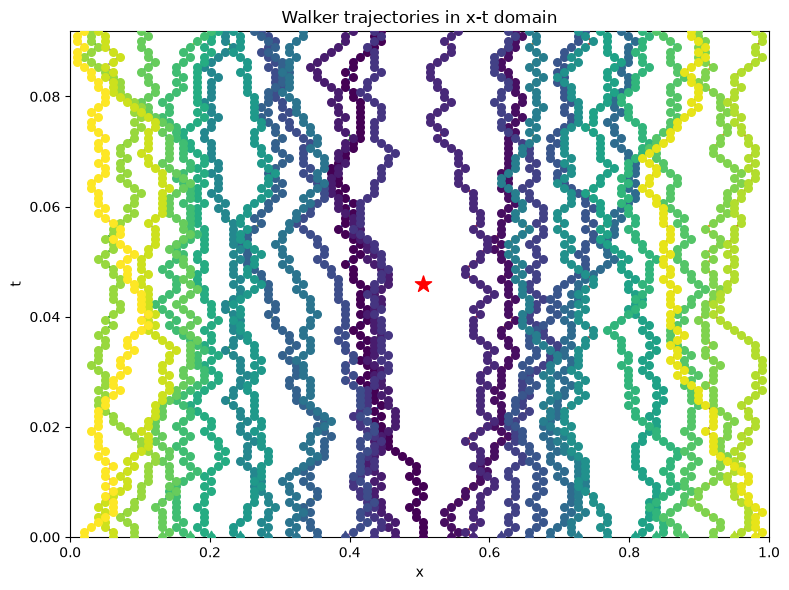

In [70]:
t_star_steps = 50  # ← change this to test different targets
env      = PDEEnvironment(t_star_steps=t_star_steps)
state, _ = env.reset()

trajectories = {i: [(env.walker_x[i], env.walker_t[i])] for i in range(env.N)}

done           = False
total_accepted = 0
total_rejected = {}

while not done:
    action = env.action_space.sample()
    state, reward, done, _, info = env.step(action)



    total_accepted += int(info['accepted'])
    if info['rejected']:
        reason = info['rejected']
        total_rejected[reason] = total_rejected.get(reason, 0) + 1

    if info['accepted']:
        i = info['walker']
        trajectories[i].append((env.walker_x[i], env.walker_t[i]))

visited_log = [(x, t) for (x, t, _) in env.visited._pts
               if t > 0.0 and 0.0 < x < 1.0]

print(f"Steps:          {env.step_count}")
print(f"Reward:         {reward:.6f}")
print(f"Reached:        {info.get('reached', False)}")
print(f"Timeout:        {info.get('timeout', False)}")
print(f"Total accepted: {total_accepted}")
print(f"Total rejected: {sum(total_rejected.values())}")
print("Rejection reasons:")

for reason, count in sorted(total_rejected.items(), key=lambda kv: -kv[1]):
    print(f"  {reason:10s}: {count}")
# walker distribution check — tells you if one walker is dominating
walker_counts = {}
for i, traj in trajectories.items():
    walker_counts[i] = len(traj) - 1  # subtract starting position
print("\nAccepted moves per walker:")
for i, count in sorted(walker_counts.items()):
    print(f"  Walker {i:d}: {count}")

fig, ax = plt.subplots(figsize=(8, 6))

vx = [p[0] for p in visited_log]
vt = [p[1] for p in visited_log]
ax.scatter(vx, vt, s=4, color='lightgray', zorder=1, label='Visited')

colors = plt.cm.viridis(np.linspace(0, 1, env.N))
for i, traj in trajectories.items():
    xs = [p[0] for p in traj]
    ts = [p[1] for p in traj]
    ax.plot(xs, ts, '-', linewidth=1.5, zorder=2)
    ax.scatter(xs, ts, s=30, color=colors[i], zorder=3)
    ax.scatter(xs[0], ts[0], s=80, color=colors[i],
               marker='^', zorder=4, label=f'Walker {i}')

ax.scatter(env.x_star, env.t_star, s=150, color='red',
           marker='*', zorder=5, label='z*')

ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_title('Walker trajectories in x-t domain')
ax.set_xlim(0, 1)
ax.set_ylim(0, env.t_star * 2)
plt.tight_layout()
plt.show()

## Plot Trajactories


In [71]:
def plot_trajectories(model, t_star_steps, N_particles, lam, beta, K_max, c_shape,
                      save=True, timestep=None, img_dir=".", label=None,
                      x_star_steps=None):          # NEW: grid index for x*; None → center
    env = PDEEnvironment(t_star_steps=t_star_steps, N_particles=N_particles,
                         lam=lam, beta=beta, K_max=K_max, c_shape=c_shape,
                         x_star_schedule=None if x_star_steps is None else [x_star_steps])
    obs, _ = env.reset()
    trajectories = {i: [(env.walker_x[i], env.walker_t[i])] for i in range(env.N)}
    done = False

    while not done:
        action, _ = model.predict(obs, deterministic=True, action_masks=env.action_masks())
        obs, reward, done, _, info = env.step(action)
        if info['accepted']:
            i = info['walker']
            trajectories[i].append((env.walker_x[i], env.walker_t[i]))

    visited_log = [(x, t) for (x, t, _) in env.visited._pts]
    fig, ax = plt.subplots(figsize=(8, 6))

    vx = [p[0] for p in visited_log]
    vt = [p[1] for p in visited_log]
    ax.scatter(vx, vt, s=4, color='lightgray', zorder=1)

    # ── Rejected positions ───────────────────────────────────────────────────
    rej_colors = {
        'bounds':    'blue',
        'collision': 'orange',
        'cond':      'purple',
        'weights':   'brown',
        'geometry':  'red',
        None:        'gray',
    }
    if env.rejected_history:
        from collections import defaultdict
        by_reason = defaultdict(list)
        for (rx, rt, reason) in env.rejected_history:
            by_reason[reason].append((rx, rt))
        for reason, pts in by_reason.items():
            ax.scatter([p[0] for p in pts], [p[1] for p in pts],
                       s=6, alpha=0.08, linewidths=0, zorder=1,
                       color=rej_colors.get(reason, 'gray'),
                       label=f'rej:{reason} ({len(pts)})')
    # ─────────────────────────────────────────────────────────────────────────

    colors = plt.cm.viridis(np.linspace(0, 1, env.N))
    for i, traj in trajectories.items():
        xs = [p[0] for p in traj]
        ts = [p[1] for p in traj]
        ax.plot(xs, ts, '-', linewidth=1.5, color=colors[i], zorder=2)
        ax.scatter(xs, ts, s=30, color=colors[i], zorder=3)
        ax.scatter(xs[0], ts[0], s=80, color=colors[i], marker='^', zorder=4)

    reached = info.get('reached', False)
    outcome = 'reached' if reached else 'timeout'

    # ── Stencil at z* ────────────────────────────────────────────────────────
    if reached:
        _, success, nb_coords, _ = env._gfdm_solve(env.x_star, env.t_star)
        if success and nb_coords is not None:
            for (nx_, nt_) in nb_coords:
                ax.plot([env.x_star, nx_], [env.t_star, nt_],
                        '--', color='red', linewidth=0.8,
                        alpha=0.7, zorder=5)
            ax.scatter(nb_coords[:, 0], nb_coords[:, 1],
                       s=40, color='red', zorder=6, alpha=0.7)

    ax.scatter(env.x_star, env.t_star, s=150, color='red', marker='*', zorder=7)
    ax.set_xlabel('x')
    ax.set_ylabel('t')

    title = f't_star={t_star_steps}·dt  |  x_star={env.x_star:.2f}  |  {outcome}'
    if timestep is not None:
        title += f'  |  step {timestep:,}'
    if reached and info.get('error') is not None:
        title += f'  |  err={info["error"]:.2e}  |  k={info["k_term"]}'
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, env.t_star * 2)

    if env.rejected_history:
        ax.legend(fontsize=6, loc='upper left', markerscale=2)

    plt.tight_layout()

    if save:
        xtag = "" if x_star_steps is None else f"_x{x_star_steps}"

        if label is not None:
            fname = f'traj_t{t_star_steps}dt{xtag}_{label}_{outcome}.png'
        elif timestep is not None:
            fname = f'traj_t{t_star_steps}dt{xtag}_{timestep//1000:05d}k_{outcome}.png'
        else:
            fname = f'traj_t{t_star_steps}dt{xtag}_{outcome}.png'
        fig.savefig(os.path.join(img_dir, fname), dpi=120)
        plt.close(fig)
    else:
        plt.show()

In [72]:
class ReachedRateCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.buf       = []
        self.kterm_buf = []
        self.err_buf   = []

    def _on_step(self) -> bool:
        for info in self.locals['infos']:
            if info.get('reached'):
                self.buf.append(1)
                k = info.get('k_term')
                e = info.get('error')
                if k is not None and e is not None:
                    self.kterm_buf.append(k)
                    self.err_buf.append(e)
            elif info.get('timeout'):
                self.buf.append(0)
        if self.buf:
            self.logger.record('rollout/reached_rate',
                               sum(self.buf[-100:]) / len(self.buf[-100:]))
        if self.kterm_buf:
            self.logger.record('rollout/mean_kterm_on_reach',
                               np.mean(self.kterm_buf[-100:]))
            self.logger.record('rollout/mean_error_on_reach',
                               np.mean(self.err_buf[-100:]))
        return True

In [73]:
class PlotCallback(BaseCallback):
    def __init__(self, t_star_steps, N_particles, lam, beta, K_max, c_shape,
                 plot_freq=50_000, img_dir=".", verbose=0,
                 x_star_steps=None):              # NEW
        super().__init__(verbose)
        self.t_star_steps = t_star_steps
        self.N_particles  = N_particles
        self.lam          = lam
        self.beta         = beta
        self.K_max        = K_max
        self.c_shape      = c_shape
        self.plot_freq    = plot_freq
        self.last_plot_at = 0
        self.img_dir      = img_dir
        self.x_star_steps = x_star_steps          # NEW

    def _on_step(self) -> bool:
        if self.num_timesteps - self.last_plot_at >= self.plot_freq:
            self.last_plot_at = self.num_timesteps
            plot_trajectories(self.model, self.t_star_steps, self.N_particles,
                              self.lam, self.beta, self.K_max, self.c_shape,
                              save=True, timestep=self.num_timesteps,
                              img_dir=self.img_dir,
                              x_star_steps=self.x_star_steps)   # NEW
        return True


def make_env(t_star_schedule, N_particles, lam, beta, K_max, c_shape, x_star_schedule):
    def _init():
        env = PDEEnvironment(t_star_schedule=t_star_schedule, N_particles=N_particles,
                             lam=lam, beta=beta, K_max=K_max, c_shape=c_shape,
                             x_star_schedule=x_star_schedule)
        env = ActionMasker(env, lambda e: e.action_masks())
        return Monitor(env)
    return _init

In [74]:
N_particles     = 80
t_star_schedule = {50: 1000}
x_star_schedule = [50]
seeds           = [55]

# ── coefficients from the recipe, for THIS horizon ──
# e_typ ≈ 0.03 (measured from your own run log), K_max = 1000
lam             = 0.0005     # = 0.5 / K_max      (was 0.005)
beta            = 150        # ≈ 5 / e_typ        (was 20000)
c_shape         = 1       # normalized potential; total shaping mass = 0.5

n_envs          = 15
total_timesteps = 2_000_000

n_steps    = 1024          # per env → buffer = 15,360 ≈ 16 episodes per update
batch_size = 256           # scale with the buffer; 60 minibatches on 15k samples is churn

In [75]:
# ── Reward decomposition sanity check ────────────────────────────────────────
chk_env = PDEEnvironment(t_star_schedule={50: 1000}, N_particles=80,
                         lam=lam, beta=beta, c_shape=c_shape,
                         x_star_schedule=[50])

expected_fail = -beta * chk_env.E_CAP - lam * 1000 - chk_env.MARGIN
print(f"Expected fail reward : {expected_fail:.4f}")
print(f"Worst possible reach : {-beta * chk_env.E_CAP - lam * 1000:.4f}  (must be > fail)")

for ep in range(3):
    obs, _ = chk_env.reset()
    print(f"\nEpisode {ep}: Phi(s0) = {chk_env._phi_prev:.4f}  (should be ≈ -{c_shape})")
    done, ep_rew, shp_sum, term_rew = False, 0.0, 0.0, None
    while not done:
        a = chk_env.action_space.sample()
        obs, r, done, _, inf = chk_env.step(a)
        ep_rew += r
        shp_sum += inf['shaping']
        if done:
            term_rew = r - inf['shaping']
    tag = 'REACHED' if inf.get('reached') else 'timeout'
    print(f"  {tag} | ep_rew={ep_rew:.4f} | shaping_sum={shp_sum:.4f} "
          f"(≈ +{c_shape}) | terminal={term_rew:.4f}")
    if inf.get('timeout'):
        assert abs(term_rew - expected_fail) < 1e-9, "timeout != fail floor — reward drifted!"
    if inf.get('reached') and inf.get('error') is not None:
        print(f"    err={inf['error']:.4e} | r_acc={inf['r_acc']:.4f} | r_eff={inf['r_eff']:.4f}")
print("\nAll checks passed." )

Expected fail reward : -9.0000
Worst possible reach : -8.0000  (must be > fail)

Episode 0: Phi(s0) = -1.0000  (should be ≈ -1)
  timeout | ep_rew=-8.0000 | shaping_sum=1.0000 (≈ +1) | terminal=-9.0000

Episode 1: Phi(s0) = -1.0000  (should be ≈ -1)
  timeout | ep_rew=-8.0000 | shaping_sum=1.0000 (≈ +1) | terminal=-9.0000

Episode 2: Phi(s0) = -1.0000  (should be ≈ -1)
  timeout | ep_rew=-8.0000 | shaping_sum=1.0000 (≈ +1) | terminal=-9.0000

All checks passed.


In [76]:


plot_tstar   = 50
plot_K_max   = t_star_schedule[plot_tstar]
plot_xstar   = x_star_schedule[0]
 

# ── Run directory ────────────────────────────────────────────────────────────
day        = date.today().day
stages_str = "-".join(str(s) for s in t_star_schedule.keys())
run_name   = f"t{stages_str}_lam{lam}_beta{beta}_N{N_particles}_c{c_shape}"
run_dir    = os.path.join(f"runs_rewardiff{day}", run_name)

print(f"Run: {run_dir}")
print(f"Training jointly on t*={list(t_star_schedule.keys())}  "
      f"(periodic plots shown at t*={plot_tstar})")

for seed in seeds:

    seed_dir  = os.path.join(run_dir, f"seed{seed}")
    img_dir   = os.path.join(seed_dir, "images")
    ckpt_dir  = os.path.join(seed_dir, "checkpoints")

    os.makedirs(img_dir,  exist_ok=True)
    os.makedirs(ckpt_dir, exist_ok=True)

    print(f"\n{'#'*50}\nSEED {seed}\n{'#'*50}")

    # every subprocess gets the SAME schedule and resamples t* per episode in reset()
    vec_env = SubprocVecEnv([
        make_env(t_star_schedule, N_particles, lam, beta, K_max=None,
                c_shape=c_shape, x_star_schedule=x_star_schedule)
        for _ in range(n_envs)
    ])

    model = MaskablePPO(
        "MlpPolicy",
        vec_env,
        verbose=1,
        seed=seed,
        tensorboard_log=os.path.join(seed_dir, "logs"),
        learning_rate=2e-4,
        clip_range=0.1,
        n_steps=n_steps,
        batch_size=batch_size,
        gamma=1.0,
        ent_coef=0.01,
        device="cpu",
    )

    print(f"\n{'='*50}")
    print(f"Joint training over t* schedule: {t_star_schedule}")
    print(f"budget: {total_timesteps//1000}k steps")
    print(f"{'='*50}")

    model.learn(
        total_timesteps=total_timesteps,
        reset_num_timesteps=False,
        tb_log_name=f"seed{seed}",
        log_interval=10,
        callback=[
            ReachedRateCallback(),
            PlotCallback(plot_tstar, N_particles, lam, beta, plot_K_max, c_shape,
                            plot_freq=100_000, img_dir=img_dir, x_star_steps=plot_xstar),
            CheckpointCallback(
                save_freq=100_000,
                save_path=os.path.join(ckpt_dir, "sched"),
                name_prefix="sched"
            ),
        ],
    )

    model.save(os.path.join(ckpt_dir, "sched_final"))

    # final plots/videos at the representative t*
    plot_trajectories(model, plot_tstar, N_particles, lam, beta, plot_K_max, c_shape,
                  save=True, timestep=None, img_dir=img_dir, label="final",
                  x_star_steps=plot_xstar)
    make_training_progress_video(img_dir, plot_tstar, N_particles, lam, beta, plot_K_max, c_shape,
                                 label="final", fps=5)
    make_trajectory_video1(
        model, PDEEnvironment, plot_tstar, N_particles,
        img_dir=img_dir, label="final",
        x_star_steps=plot_xstar,
    )

Run: runs_rewardiff22\t50_lam0.0005_beta150_N80_c1
Training jointly on t*=[50]  (periodic plots shown at t*=50)

##################################################
SEED 55
##################################################
Using cpu device

Joint training over t* schedule: {50: 1000}
budget: 2000k steps
Logging to runs_rewardiff22\t50_lam0.0005_beta150_N80_c1\seed55\logs\seed55_0
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1e+03       |
|    ep_rew_mean          | -8          |
|    reached_rate         | 0           |
| time/                   |             |
|    fps                  | 1519        |
|    iterations           | 10          |
|    time_elapsed         | 101         |
|    total_timesteps      | 153600      |
| train/                  |             |
|    approx_kl            | 0.003517046 |
|    clip_fraction        | 0.168       |
|    clip_range           | 0.1         |
|    entropy_loss         | -

Exception ignored in: <_io.BytesIO object at 0x00000224E7E97510>
Traceback (most recent call last):
  File "c:\Users\amt35\OneDrive\RL For PDEs\Taylor linear predictor\venv\Lib\site-packages\matplotlib\_api\__init__.py", line 226, in check_in_list
    if not exists:
BufferError: Existing exports of data: object cannot be re-sized


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 998          |
|    ep_rew_mean          | -7.97        |
|    mean_error_on_reach  | 0.0649       |
|    mean_kterm_on_reach  | 932          |
|    reached_rate         | 0.03         |
| time/                   |              |
|    fps                  | 1500         |
|    iterations           | 60           |
|    time_elapsed         | 614          |
|    total_timesteps      | 921600       |
| train/                  |              |
|    approx_kl            | 0.0038426942 |
|    clip_fraction        | 0.206        |
|    clip_range           | 0.1          |
|    entropy_loss         | -4.84        |
|    explained_variance   | 0.961        |
|    learning_rate        | 0.0002       |
|    loss                 | 0.0377       |
|    n_updates            | 590          |
|    policy_gradient_loss | -0.00513     |
|    value_loss           | 0.141        |
-----------

TypeError: make_training_progress_video() got an unexpected keyword argument 'label'

Rollout done: timeout, 206 accepted points, 500 total steps.


KeyboardInterrupt: 

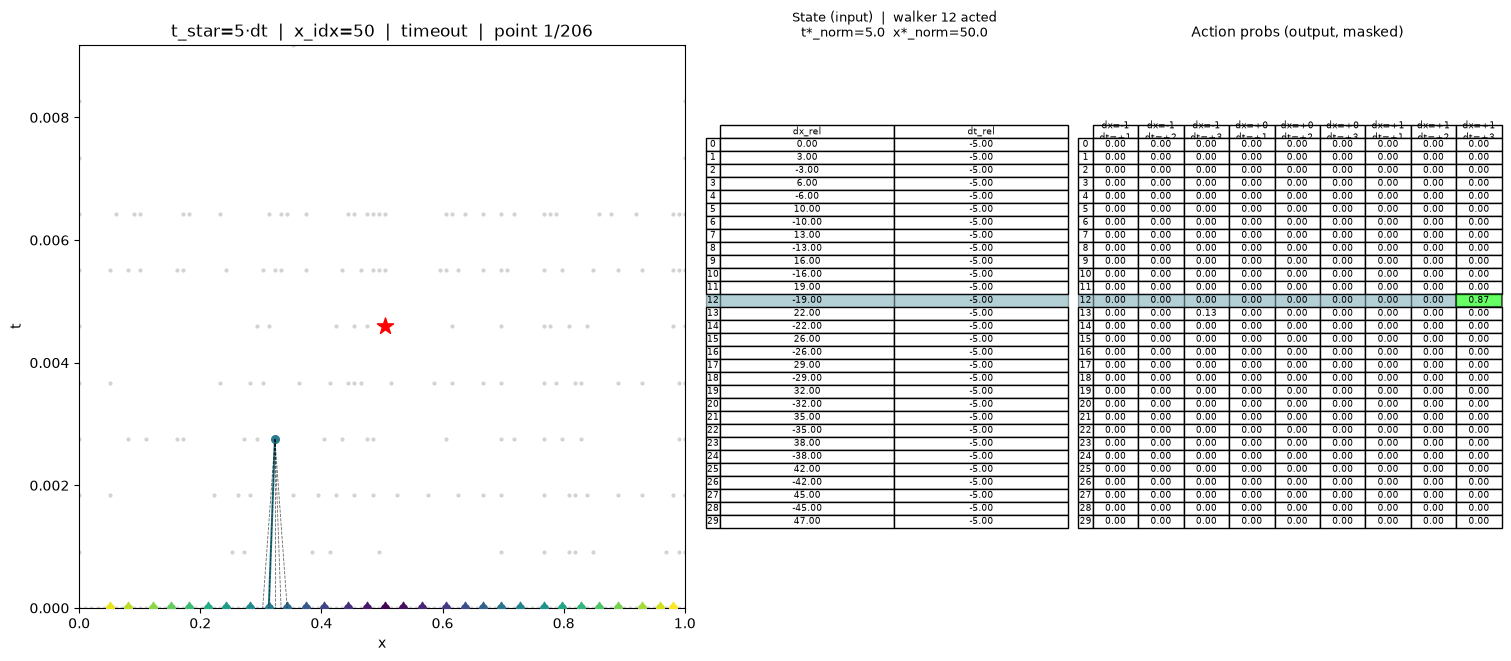

In [ ]:
make_trajectory_video1(
        model, PDEEnvironment, plot_tstar, N_particles,
        img_dir=img_dir, label="final",
        x_star_steps=50,
)